# Занятие 27. Логистическая регрессия

Линейная регрессия предсказывала число. Теперь научимся предсказывать **класс** и оценивать вероятность этого класса: например, сдаст ли ученик экзамен или является ли письмо спамом.

К концу занятия вы сможете:

- отличать классификацию от регрессии и кластеризации;
- объяснять, как линейная комбинация признаков превращается в оценку вероятности;
- пользоваться `LogisticRegression`, `predict` и `predict_proba`;
- читать матрицу ошибок и выбирать подходящую метрику;
- понимать влияние порога, дисбаланса классов и регуляризации;
- замечать случаи, когда линейной границы недостаточно.


## 1. Задача классификации

В **обучении с учителем** у каждого учебного объекта есть правильный ответ. Если ответ является категорией, решается задача **классификации**.

| Признаки объекта | Ответ |
|---|---|
| текст письма, отправитель | спам / не спам |
| результаты обследования | заболевание есть / нет |
| изображение животного | кошка / собака / птица |

- Два возможных класса — **бинарная классификация**.
- Три и более — **многоклассовая классификация**.

Классы часто кодируют числами 0 и 1, но это именно метки, а не обычные числовые величины: между классами 0 и 1 нет «половины класса».

Сравним три знакомых типа задач:

| Задача | Есть правильные ответы? | Что ищем? |
|---|---|---|
| кластеризация | нет | группы похожих объектов |
| регрессия | да | число |
| классификация | да | категорию |

**Сквозной пример:** часы подготовки и сдача экзамена (0 — не сдал, 1 — сдал):

| часы подготовки | сдал экзамен |
|-----------------|--------------|
| 1.0 | 0 |
| 2.0 | 0 |
| 2.5 | 0 |
| 3.0 | 0 |
| 4.0 | 0 |
| 5.0 | 1 |
| 6.0 | 1 |
| 6.5 | 0 |
| 7.5 | 1 |
| 8.0 | 1 |


In [66]:
import numpy as np
import matplotlib.pyplot as plt

hours = np.array([1, 2, 2.5, 3, 4, 5, 6, 6.5, 7.5, 8], dtype=float)
passed = np.array([0, 0, 0, 0, 0, 1, 1, 0, 1, 1])


,часы подготовки,сдал экзамен
0,1.0,0
1,2.0,0
2,2.5,0
3,3.0,0
4,4.0,0
5,5.0,1
6,6.0,1
7,6.5,0
8,7.5,1
9,8.0,1


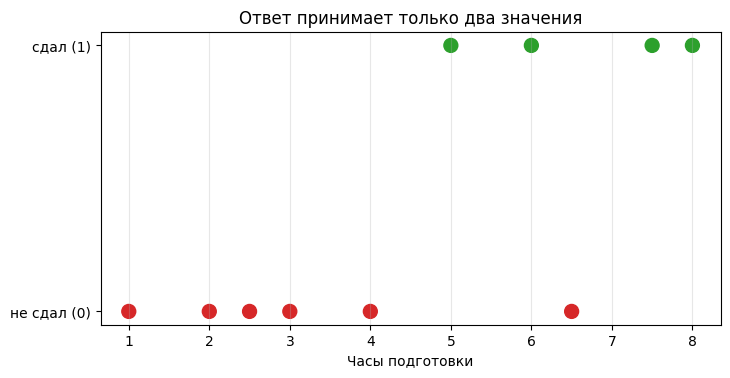

In [67]:
plt.figure(figsize=(8, 3.8))
colors = np.where(passed == 1, 'tab:green', 'tab:red')
plt.scatter(hours, passed, c=colors, s=100)
plt.yticks([0, 1], ['не сдал (0)', 'сдал (1)'])
plt.xlabel('Часы подготовки')
plt.title('Ответ принимает только два значения')
plt.grid(axis='x', alpha=0.3)
plt.show()


## 2. Классы и вероятности

Мы не можем точно определить, к какому классу принадлежит тот или иной объект, поэтому мы хотим предсказывать *вероятность* $p$ принадлежности 
объекта к классу 1 (в случае бинарной классификации). Вероятность~--- это число от 0 до 1. В алгоритме линейной регрессии мы умеем предсказывать число от -∞ до +∞.

Можно провести через нули и единицы прямую линейной регрессии, но у неё возникают проблемы:

- прогноз может оказаться меньше 0 или больше 1;
- прямая не обязана вести себя как вероятность;
- выход прямой нельзя напрямую интерпретировать как степень уверенности модели.

Нам нужна модель, которая выдаёт число строго между 0 и 1.


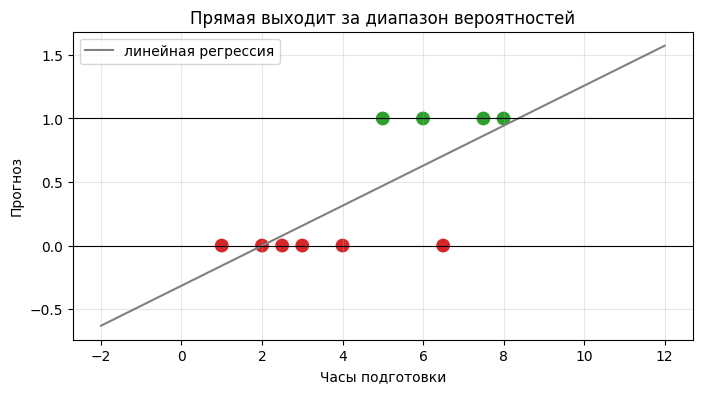

In [68]:
from sklearn.linear_model import LinearRegression

linear_classifier = LinearRegression().fit(hours.reshape(-1, 1), passed)
grid_1d = np.linspace(-2, 12, 200).reshape(-1, 1)

plt.figure(figsize=(8, 4))
plt.scatter(hours, passed, c=np.where(passed == 1, 'tab:green', 'tab:red'), s=80)
plt.plot(grid_1d, linear_classifier.predict(grid_1d), color='gray', label='линейная регрессия')
plt.axhline(0, color='black', linewidth=0.8)
plt.axhline(1, color='black', linewidth=0.8)
plt.xlabel('Часы подготовки'); plt.ylabel('Прогноз')
plt.title('Прямая выходит за диапазон вероятностей')
plt.grid(alpha=0.3); plt.legend(); plt.show()


## 3. Логит и сигмоида

Покажем сначала, как можно преобразовать вероятность (число от 0 до 1) в число от -∞ до +∞. А затем воспользуемся обратной функцией, чтобы преобразовывать прогноз модели в вероятность.

Сначала преобразуем вероятность в *шансы*. Вы все слышали выражение "шансы Спартака на победу - два к одному". Это означает, что вероятность его победы 2/3. Формально, шансы (odds) это отношение вероятности победы к вероятности поражения: $odds=\frac{p}{1-p}$. Это число принимает значения от 0 (когда p=0) до +∞ (когда p=1).
Теперь преобразуем шансы в число от -∞ до +∞: для этого достаточно воспользоваться функций log.

Получившая функция (логарифм шансов) называется логит (logit, **log**istic un**it**):
$$
logit(p)=\log\frac{p}{1-p}.
$$

Несложно вычислить обратную функцию (ее называют *сигмоидой*):
$$
p = \sigma(z)=\frac{e^z}{e^z+1}=\frac{1}{1+e^{-z}}.
$$

Теперь вернемся к нашей задаче определение вероятности того, что объект принадлежит классу 1 по его признакам $x_1,\dots,x_p$. 
Решать ее мы будем следующим образом

Сначала модель считает знакомую **линейную комбинацию признаков**:

$$z=w_1x_1+w_2x_2+\ldots+w_px_p+b.$$

Линейная комбинация может быть любым числом. Его называют *логит*, поскольку он равен $logit(p)$. Чтобы получить оценку вероятности класса 1, применяется **сигмоида**, обратная функция к функции $logit$:

$$p(y=1)=\sigma(z)=\frac{1}{1+e^{-z}}.$$

- при большом отрицательном $z$ вероятность близка к 0;
- при $z=0$ вероятность равна 0,5;
- при большом положительном $z$ вероятность близка к 1.

Значение $z$ остаётся линейной комбинацией признаков, хотя график оценки вероятности имеет форму буквы S.


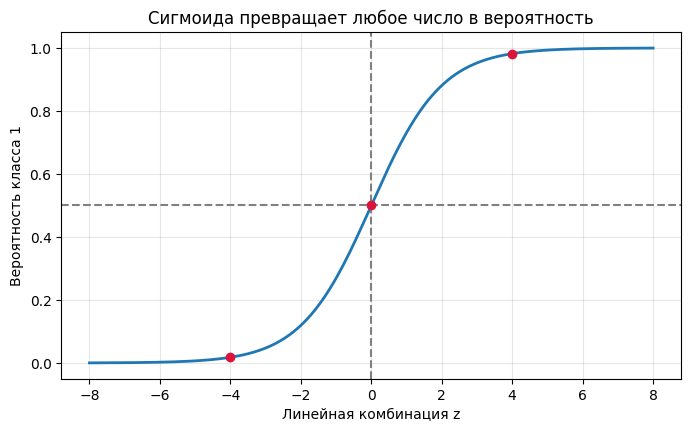

z=-4: вероятность=0.018
z= 0: вероятность=0.500
z= 4: вероятность=0.982


In [69]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

z_grid = np.linspace(-8, 8, 300)
plt.figure(figsize=(8, 4.5))
plt.plot(z_grid, sigmoid(z_grid), linewidth=2)
plt.axvline(0, color='gray', linestyle='--')
plt.axhline(0.5, color='gray', linestyle='--')
plt.scatter([-4, 0, 4], sigmoid(np.array([-4, 0, 4])), color='crimson', zorder=3)
plt.xlabel('Линейная комбинация z'); plt.ylabel('Вероятность класса 1')
plt.title('Сигмоида превращает любое число в вероятность')
plt.ylim(-0.05, 1.05); plt.grid(alpha=0.3); plt.show()

for z in [-4, 0, 4]:
    print(f'z={z:>2}: вероятность={sigmoid(z):.3f}')


## 4. Вероятность, порог и класс

Как перейти от вероятности к прогнозу класса?

1. Модель вычисляет вероятность $p$ класса 1.
2. Мы выбираем **порог** (threshold) $t$.
3. Если $p\ge t$, прогнозируем класс 1, иначе класс 0.

Часто начинают с порога 0,5. Тогда граница решений соответствует $p=0{,}5$, то есть $z=0$.

Порог — решение пользователя модели. Его можно изменить без повторного обучения.


In [70]:
probabilities = np.array([0.12, 0.43, 0.51, 0.78, 0.96])
for threshold in [0.5, 0.8]:
    labels = (probabilities >= threshold).astype(int)
    print(f'Порог {threshold}: {labels}')


Порог 0.5: [0 0 1 1 1]
Порог 0.8: [0 0 0 0 1]


## 5. Логистическая регрессия в sklearn

`LogisticRegression` подбирает коэффициенты линейной комбинации. Основные методы:

- `fit(X, y)` — обучить модель;
- `decision_function(X)` — получить значение линейной комбинации $z$;
- `predict_proba(X)` — получить оценки вероятностей классов; порядок столбцов ответа хранится в `classes_` (при обучении алгоритм сам находит все уникальные классы);
- `predict(X)` — получить итоговые классы с порогом 0,5.

Несмотря на слово «регрессия» в названии, это алгоритм **классификации**.


In [71]:
import pandas as pd
from sklearn.linear_model import LogisticRegression

X_one = hours.reshape(-1, 1)
logistic = LogisticRegression().fit(X_one, passed)

examples = np.array([[3], [5], [8]])
result = pd.DataFrame({
    'часы': examples.ravel(),
    'линейная комбинация z': logistic.decision_function(examples),
    'P(не сдал)': logistic.predict_proba(examples)[:, 0],
    'P(сдал)': logistic.predict_proba(examples)[:, 1],
    'класс': logistic.predict(examples),
})
print('Порядок классов в столбцах predict_proba:', logistic.classes_)
result.round(3)


Порядок классов в столбцах predict_proba: [0 1]


,часы,линейная комбинация z,P(не сдал),P(сдал),класс
0,3,-2.063,0.887,0.113,0
1,5,-0.355,0.588,0.412,0
2,8,2.206,0.099,0.901,1


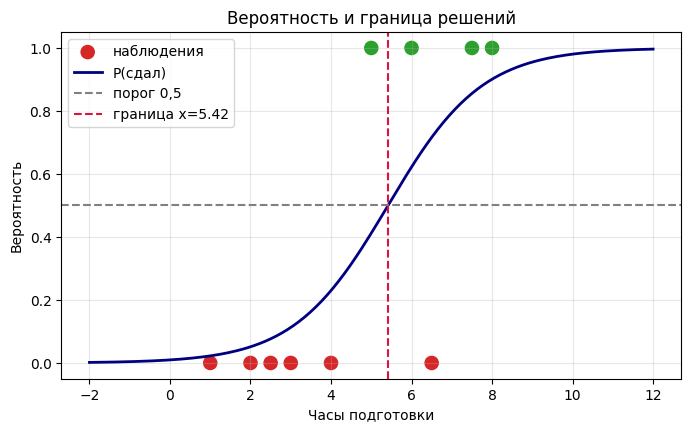

In [72]:
prob_grid = logistic.predict_proba(grid_1d)[:, 1]
boundary = -logistic.intercept_[0] / logistic.coef_[0, 0]

plt.figure(figsize=(8, 4.5))
plt.scatter(hours, passed, c=np.where(passed == 1, 'tab:green', 'tab:red'), s=90, label='наблюдения')
plt.plot(grid_1d, prob_grid, color='navy', linewidth=2, label='P(сдал)')
plt.axhline(0.5, color='gray', linestyle='--', label='порог 0,5')
plt.axvline(boundary, color='crimson', linestyle='--', label=f'граница x={boundary:.2f}')
plt.xlabel('Часы подготовки'); plt.ylabel('Вероятность')
plt.title('Вероятность и граница решений')
plt.ylim(-0.05, 1.05); plt.grid(alpha=0.3); plt.legend(); plt.show()


## 6. Как обучается модель: log loss и оптимизация *

Для обучения модели нам нужно сконструировать функцию потерь. Рассмотрим один прогноз. Если правильный класс $y_i=1$, а мы предсказали вероятность этого класса как p, то добавим в штраф $-ln(p)$.

Идея проста:

- правильный уверенный прогноз получает маленький штраф;
- неуверенный прогноз получает средний штраф;
- уверенный неправильный прогноз получает очень большой штраф.

Если же правильный класс $y_i=0$, то добавим в штраф $-ln(1-p)$.

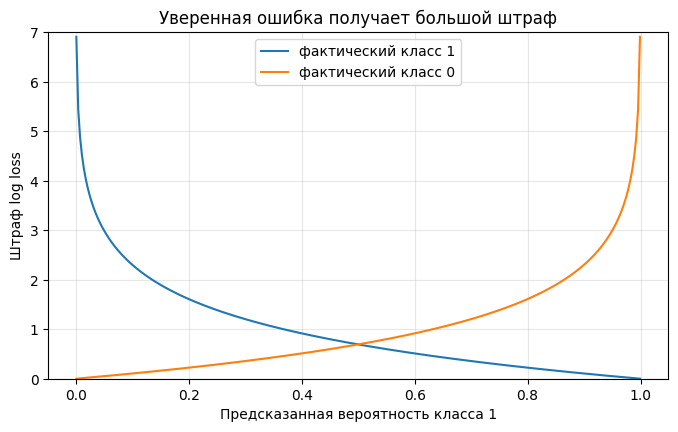

In [73]:
p = np.linspace(0.001, 0.999, 300)
loss_if_one = -np.log(p)
loss_if_zero = -np.log(1 - p)

plt.figure(figsize=(8, 4.5))
plt.plot(p, loss_if_one, label='фактический класс 1')
plt.plot(p, loss_if_zero, label='фактический класс 0')
plt.xlabel('Предсказанная вероятность класса 1')
plt.ylabel('Штраф log loss')
plt.title('Уверенная ошибка получает большой штраф')
plt.ylim(0, 7); plt.grid(alpha=0.3); plt.legend(); plt.show()



Вместе этот штраф можно записать так: $-(y_i\ln p_i+(1-y_i)\ln(1-p_i))$ (одно из слагаемых в любом случае будет равно 0). 

Получившуюся функцию потерь называют **логарифмическая функция потерь** (*log loss*, или бинарная кросс-энтропия):

$$L=-\frac1n\sum_{i=1}^n\left[y_i\ln p_i+(1-y_i)\ln(1-p_i)\right].$$

`LogisticRegression` из sklearn по умолчанию минимизирует не просто log loss, а сразу добавляет к нему L2-штраф за большие коэффициенты. Параметр `C` управляет силой этого штрафа; подробнее — в разделе о регуляризации.

Минимум ищется итеративным численным методом. Знакомый градиентный спуск — один из возможных общих подходов: посчитать направление роста функции и сделать шаг в противоположную сторону. Параметр `solver` задаёт конкретный алгоритм оптимизации. Например, стандартный `solver='lbfgs'` использует квазиньютоновский метод.


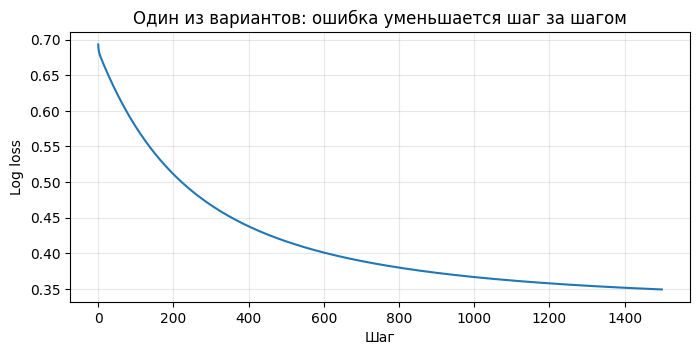

In [74]:

# Покажем общую идею итеративной оптимизации на простом градиентном спуске.
w_gd, b_gd = 0.0, 0.0
learning_rate = 0.05
loss_history = []
for step in range(1500):
    z = w_gd * hours + b_gd
    p_gd = sigmoid(z)
    eps = 1e-12
    loss = -np.mean(passed * np.log(p_gd + eps) + (1 - passed) * np.log(1 - p_gd + eps))
    loss_history.append(loss)
    w_gd -= learning_rate * np.mean((p_gd - passed) * hours)
    b_gd -= learning_rate * np.mean(p_gd - passed)

plt.figure(figsize=(8, 3.5))
plt.plot(loss_history)
plt.xlabel('Шаг'); plt.ylabel('Log loss')
plt.title('Один из вариантов: ошибка уменьшается шаг за шагом')
plt.grid(alpha=0.3); plt.show()


## 7. Учебный пример с двумя признаками

До сих пор мы работали с одним признаком — часами подготовки. Дальше в этом блокноте будем оценивать качество модели на более крупном примере с **двумя признаками**: часами подготовки и продолжительностью сна.

Модель по-прежнему считает линейную комбинацию $z=w_1\cdot\text{подготовка}+w_2\cdot\text{сон}+b$, а затем превращает $z$ в вероятность с помощью сигмоиды. Сначала создадим данные; разделение на train, validation и test сделаем в следующем разделе — непосредственно перед оценкой качества.


In [75]:
rng = np.random.default_rng(42)
n = 200
study_hours = rng.uniform(0, 10, n)
sleep_hours = rng.uniform(4, 10, n)
true_score = 0.9 * study_hours + 0.55 * sleep_hours - 7.2 + rng.normal(0, 1.2, n)
y = (true_score > 0).astype(int)
X = pd.DataFrame({'подготовка': study_hours, 'сон': sleep_hours})

print(f'Объектов: {len(X)}, доля класса 1: {y.mean():.2f}')
X.head()


Объектов: 200, доля класса 1: 0.65


,подготовка,сон
0,7.739560,8.664429
1,4.388784,9.830959
2,8.585979,7.004447
3,6.973680,4.863385
4,0.941773,4.083618


## 8. Train, validation и test

Прежде чем считать метрики и подбирать порог, данные нужно **разделить**. Это тот же принцип, что на занятии 21 о рабочем процессе ML:

- **train** — обучение коэффициентов модели;
- **validation** — оценка качества и выбор порога, пока мы ещё настраиваем решение;
- **test** — одна финальная проверка уже выбранного варианта; к нему не возвращаются при настройке.

Test похож на запечатанный вариант контрольной: если после просмотра test менять модель или порог, test перестаёт быть честной проверкой. Поэтому тестовую выборку откладываем сейчас и впервые используем только в разделе 13.

Для классификации важно сохранить примерно одинаковую долю классов во всех частях. Параметр `stratify=y` в `train_test_split` выполняет такое **стратифицированное разбиение**.

Ниже данные делятся на три части, модель обучается только на train, а прогнозы для дальнейших разделов готовятся на validation.


In [76]:
from sklearn.model_selection import train_test_split

X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.25, random_state=42, stratify=y_train_val
)

model = LogisticRegression().fit(X_train, y_train)
p_val = model.predict_proba(X_val)[:, 1]
y_val_pred = model.predict(X_val)

print('Доли класса 1:')
print(f'в исходных данных: {y.mean():.2f}')
print(f'в обучении:        {y_train.mean():.2f}')
print(f'в валидации:       {y_val.mean():.2f}')
print(f'в тесте:           {y_test.mean():.2f}')
print(f'\nРазмеры: train={len(y_train)}, val={len(y_val)}, test={len(y_test)}')


Доли класса 1:
в исходных данных: 0.65
в обучении:        0.64
в валидации:       0.66
в тесте:           0.64

Размеры: train=112, val=38, test=50


## 9. Матрица ошибок

Используем прогнозы модели на **validation** из раздела 8 — эти объекты не участвовали в обучении коэффициентов.

Для бинарной классификации каждый прогноз попадает в одну из четырёх групп:

| | Прогноз 0 | Прогноз 1 |
|---|---:|---:|
| **Факт 0** | TN — *True Negative*, верно отвергли | FP — *False Positive*, ложная тревога |
| **Факт 1** | FN — *False Negative*, пропустили | TP — *True Positive*, верно нашли |

«Положительным» называется класс 1, а не обязательно хороший исход. Например, классом 1 может быть заболевание.


TN=9, FP=4, FN=1, TP=24


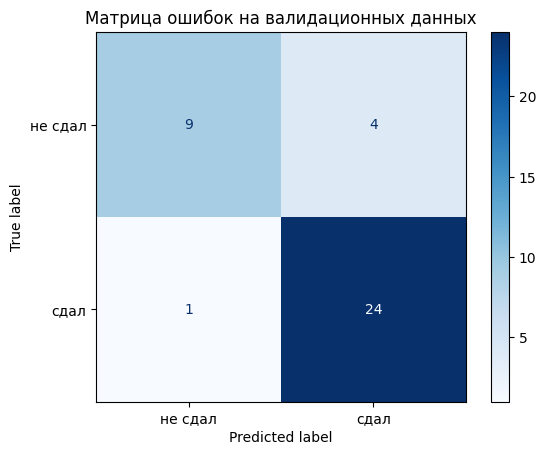

In [77]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

cm = confusion_matrix(y_val, y_val_pred)
tn, fp, fn, tp = cm.ravel()
print(f'TN={tn}, FP={fp}, FN={fn}, TP={tp}')

ConfusionMatrixDisplay(cm, display_labels=['не сдал', 'сдал']).plot(cmap='Blues')
plt.title('Матрица ошибок на валидационных данных')
plt.show()


## 10. Метрики классификации

$$Accuracy=\frac{TP+TN}{TP+TN+FP+FN}$$

$$Precision=\frac{TP}{TP+FP},\qquad Recall=\frac{TP}{TP+FN}$$

$$F1=\frac{2}{\frac{1}{Precision}+\frac{1}{Recall}}=2\cdot\frac{Precision\cdot Recall}{Precision+Recall}$$

- **Accuracy** — доля всех правильных ответов.
- **Precision** — как часто модель права, когда говорит «класс 1».
- **Recall** — какую долю настоящих объектов класса 1 модель нашла.
- **F1** — среднее гармоническое precision и recall (более жестко штрафует за провал каждого, стимулирует к балансу)

Нет лучшей метрики для всех задач. Для опасного заболевания особенно дорог FN, поэтому важен recall. Для дорогой ручной проверки ложные тревоги FP могут сделать процесс бесполезным, поэтому важен precision.


In [78]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print('Метрики при начальном пороге 0,5 на validation:')
print(f'Accuracy:  {accuracy_score(y_val, y_val_pred):.3f}')
print(f'Precision: {precision_score(y_val, y_val_pred):.3f}')
print(f'Recall:    {recall_score(y_val, y_val_pred):.3f}')
print(f'F1:        {f1_score(y_val, y_val_pred):.3f}')


Метрики при начальном пороге 0,5 на validation:
Accuracy:  0.868
Precision: 0.857
Recall:    0.960
F1:        0.906


## 11. Baseline для классификации

Перед сложной моделью нужен простой соперник — **baseline**. Сравнивать модель нужно с baseline на **одних и тех же** данных.


## 12. Дисбаланс классов и выбор метрики

Если 95% писем не являются спамом, модель «всегда не спам» получит accuracy 95%, хотя не найдёт ни одного спам-письма.

Такой перекос называется **дисбалансом классов**. Поэтому нужно:

1. смотреть доли классов;
2. не ограничиваться accuracy;
3. выбирать метрику по цене FP и FN.


In [79]:
from sklearn.datasets import make_classification
from sklearn.dummy import DummyClassifier

X_imb, y_imb = make_classification(
    n_samples=800, n_features=5, n_informative=3, n_redundant=0,
    weights=[0.92, 0.08], class_sep=1.0, random_state=42
)
X_imb_train, X_imb_control, y_imb_train, y_imb_control = train_test_split(
    X_imb, y_imb, test_size=0.3, random_state=42, stratify=y_imb
)

dummy = DummyClassifier(strategy='most_frequent').fit(X_imb_train, y_imb_train)
ordinary_imb = LogisticRegression(max_iter=1000).fit(X_imb_train, y_imb_train)

rows_imb = []
for name, estimator in [('baseline', dummy), ('логистическая регрессия', ordinary_imb)]:
    pred = estimator.predict(X_imb_control)
    rows_imb.append({
        'модель': name,
        'accuracy': accuracy_score(y_imb_control, pred),
        'precision класса 1': precision_score(y_imb_control, pred, zero_division=0),
        'recall класса 1': recall_score(y_imb_control, pred, zero_division=0),
        'F1 класса 1': f1_score(y_imb_control, pred, zero_division=0),
    })

print(f'Доля редкого класса 1 в контрольной выборке: {y_imb_control.mean():.3f}')
pd.DataFrame(rows_imb).round(3)


Доля редкого класса 1 в контрольной выборке: 0.083


,модель,accuracy,precision класса 1,recall класса 1,F1 класса 1
0,baseline,0.917,0.0,0.0,0.000
1,логистическая регрессия,0.983,1.0,0.8,0.889


## 13. Как порог меняет ошибки

Низкий порог чаще назначает класс 1:

- recall обычно растёт — положительные объекты труднее пропустить;
- precision может снизиться — ложных тревог становится больше.

Высокий порог действует наоборот. Порог выбирают на валидационных данных, а тест оставляют для финальной проверки.


In [80]:
rows = []
for threshold in np.linspace(0.15, 0.85, 15):
    pred_t = (p_val >= threshold).astype(int)
    rows.append({
        'порог': threshold,
        'precision': precision_score(y_val, pred_t, zero_division=0),
        'recall': recall_score(y_val, pred_t, zero_division=0),
        'F1': f1_score(y_val, pred_t, zero_division=0),
        'предсказано единиц': pred_t.sum(),
    })
threshold_table = pd.DataFrame(rows)
best_threshold = threshold_table.loc[threshold_table['F1'].idxmax(), 'порог']
print(f'Лучший из проверенных порогов по F1 на validation: {best_threshold:.2f}')
threshold_table.round(3)


Лучший из проверенных порогов по F1 на validation: 0.35


,порог,precision,recall,F1,предсказано единиц
0,0.15,0.781,1.00,0.877,32
1,0.20,0.806,1.00,0.893,31
2,0.25,0.833,1.00,0.909,30
3,0.30,0.833,1.00,0.909,30
4,0.35,0.862,1.00,0.926,29
5,0.40,0.857,0.96,0.906,28
6,0.45,0.857,0.96,0.906,28
7,0.50,0.857,0.96,0.906,28
8,0.55,0.857,0.96,0.906,28
9,0.60,0.889,0.96,0.923,27


## 14. Первый честный test

После выбора модели, порога и метрики на validation **один раз** открывают test. Повторные правки по test делают его оценку оптимистичной (см. занятие 29, п. 6).


## 15. ROC- и PR-кривые *

ROC и PR показывают качество **ранжирования** объектов по вероятности **без выбора одного порога**. Порог подбирают отдельно на validation (п. 13).


Финальный порог: 0.35
Test precision: 0.941
Test recall:    1.000
Test F1:        0.970


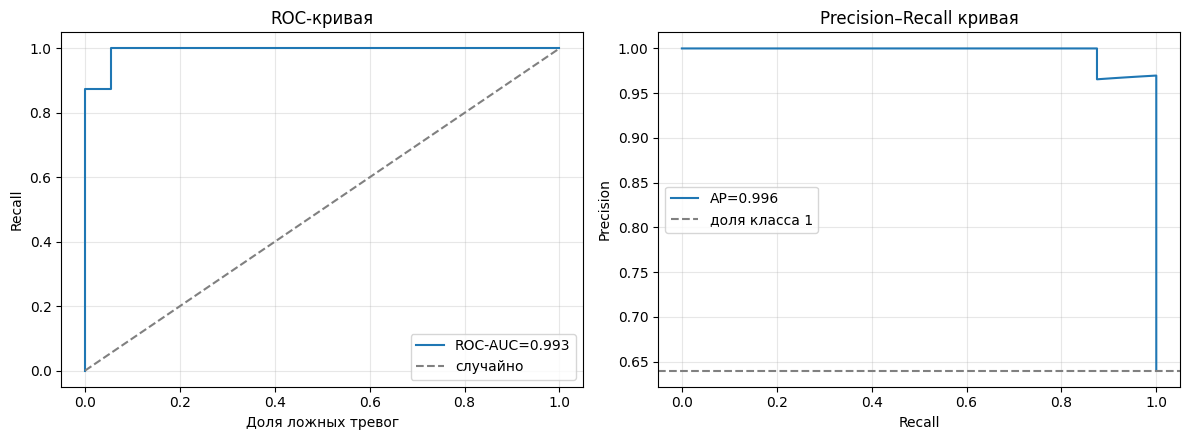

In [81]:
from sklearn.metrics import roc_curve, roc_auc_score, precision_recall_curve, average_precision_score

p_test = model.predict_proba(X_test)[:, 1]
y_test_pred = (p_test >= best_threshold).astype(int)
print(f'Финальный порог: {best_threshold:.2f}')
print(f'Test precision: {precision_score(y_test, y_test_pred, zero_division=0):.3f}')
print(f'Test recall:    {recall_score(y_test, y_test_pred, zero_division=0):.3f}')
print(f'Test F1:        {f1_score(y_test, y_test_pred, zero_division=0):.3f}')

fpr, tpr, _ = roc_curve(y_test, p_test)
precision_curve, recall_curve, _ = precision_recall_curve(y_test, p_test)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(fpr, tpr, label=f'ROC-AUC={roc_auc_score(y_test, p_test):.3f}')
axes[0].plot([0, 1], [0, 1], '--', color='gray', label='случайно')
axes[0].set_xlabel('Доля ложных тревог'); axes[0].set_ylabel('Recall')
axes[0].set_title('ROC-кривая'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(recall_curve, precision_curve,
             label=f'AP={average_precision_score(y_test, p_test):.3f}')
axes[1].axhline(y_test.mean(), linestyle='--', color='gray', label='доля класса 1')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('Precision–Recall кривая'); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()


## 16. Несколько признаков и граница решений

Для двух признаков граница $p=0{,}5$ задаётся уравнением

$$w_1x_1+w_2x_2+b=0.$$

На плоскости это прямая. С одной стороны модель выбирает класс 0, с другой — класс 1. Это граница для стандартного порога $t=0{,}5$. При другом пороге линия сдвинется и будет задаваться уравнением

$$w_1x_1+w_2x_2+b=\ln\frac{t}{1-t}.$$

При большем числе признаков получается гиперплоскость, которую уже трудно нарисовать.


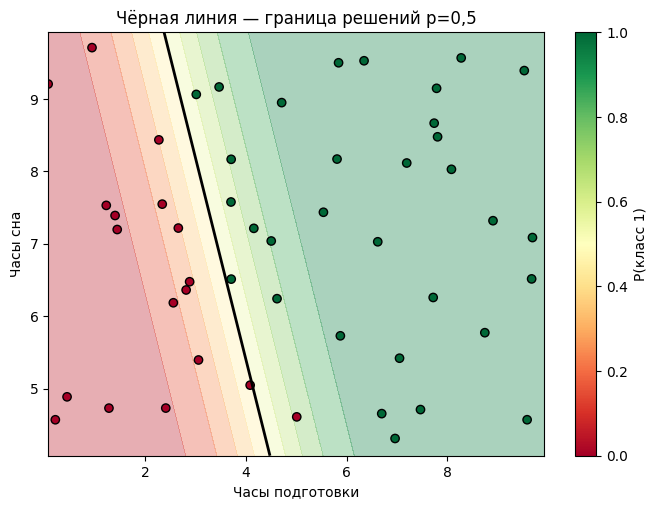

In [82]:
x1 = np.linspace(X['подготовка'].min(), X['подготовка'].max(), 160)
x2 = np.linspace(X['сон'].min(), X['сон'].max(), 160)
xx1, xx2 = np.meshgrid(x1, x2)
grid_2d = pd.DataFrame({'подготовка': xx1.ravel(), 'сон': xx2.ravel()})
surface = model.predict_proba(grid_2d)[:, 1].reshape(xx1.shape)

plt.figure(figsize=(8, 5.5))
plt.contourf(xx1, xx2, surface, levels=np.linspace(0, 1, 11), cmap='RdYlGn', alpha=0.35)
plt.contour(xx1, xx2, surface, levels=[0.5], colors='black', linewidths=2)
plt.scatter(X_test['подготовка'], X_test['сон'], c=y_test, cmap='RdYlGn', edgecolor='black')
plt.colorbar(label='P(класс 1)')
plt.xlabel('Часы подготовки'); plt.ylabel('Часы сна')
plt.title('Чёрная линия — граница решений p=0,5')
plt.show()


## 17. Как интерпретировать коэффициенты *

Знак коэффициента показывает направление связи при неизменных остальных признаках:

- $w_j>0$ — с ростом признака и фиксированных остальных признаках вероятность класса 1 растёт;
- $w_j<0$ — при тех же условиях уменьшается.

Чем больше модуль коэффициента, тем сильнее признак влияет на значение $z$. Однако сравнивать величины коэффициентов можно только у признаков одного масштаба. Например, коэффициенты температуры в градусах и тысячных долях градуса будут разными, хотя смысл признака одинаков.

Один и тот же прирост $z$ по-разному меняет вероятность около 0,5 и около 0 или 1. Поэтому нельзя сказать, что увеличение признака на единицу всегда добавляет к вероятности один и тот же процент. Коэффициенты описывают связь в данных, а не доказывают причину.


In [83]:
coef_table = pd.DataFrame({
    'признак': X.columns,
    'коэффициент': model.coef_[0],
})
coef_table.round(3)


,признак,коэффициент
0,подготовка,1.313
1,сон,0.472


## 18. Зачем масштабировать перед L1/L2

Признаки в разных единицах измерения по-разному попадают под штраф регуляризации. Перед Ridge/Lasso/ElasticNet числовые признаки обычно масштабируют (`StandardScaler`, `fit` только на train).


## 19. Параметр C и сила регуляризации

В `LogisticRegression` параметр **`C`** — обратная сила регуляризации: большой `C` — слабый штраф, малый `C` — сильный. **`l1_ratio`** задаёт долю L1 в ElasticNet. Подбирают по validation.


In [84]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

for name, estimator in [
    ('сильная L2', LogisticRegression(C=0.05, l1_ratio=0)),
    ('слабая L2', LogisticRegression(C=100, l1_ratio=0)),
    ('L1', LogisticRegression(C=0.2, l1_ratio=1, solver='liblinear')),
]:
    estimator.fit(X_train_scaled, y_train)
    print(f'{name:12}: коэффициенты {np.round(estimator.coef_[0], 3)}')
print('Наблюдение: сильная L2 сильнее сжимает веса, а L1 может сделать отдельные веса нулевыми.')


сильная L2  : коэффициенты [0.965 0.198]
слабая L2   : коэффициенты [3.997 0.891]
L1          : коэффициенты [2.03  0.212]
Наблюдение: сильная L2 сильнее сжимает веса, а L1 может сделать отдельные веса нулевыми.


## 20. Взвешивание классов

При дисбалансе можно назначить редкому классу больший вес. `class_weight='balanced'` автоматически даёт больший штраф за ошибки на редком классе.

Это не волшебное исправление: обычно recall редкого класса растёт ценой большего числа ложных тревог. Результат всё равно оценивают выбранными метриками на отдельных данных.


In [85]:
balanced_imb = LogisticRegression(class_weight='balanced', max_iter=1000).fit(X_imb_train, y_imb_train)

comparison = []
for name, estimator in [('обычная', ordinary_imb), ('balanced', balanced_imb)]:
    pred = estimator.predict(X_imb_control)
    comparison.append({
        'модель': name,
        'precision редкого класса': precision_score(y_imb_control, pred, zero_division=0),
        'recall редкого класса': recall_score(y_imb_control, pred, zero_division=0),
    })
pd.DataFrame(comparison).round(3)


,модель,precision редкого класса,recall редкого класса
0,обычная,1.000,0.8
1,balanced,0.857,0.9


## 21. Многоклассовая классификация *

Для трёх и более классов модель вычисляет несколько линейных комбинаций и превращает их в вероятности, сумма которых равна 1. `predict` выбирает класс с наибольшей вероятностью.

Метрики тоже требуют уточнения способа усреднения по классам: например, `macro` даёт каждому классу одинаковый вес, а `weighted` учитывает размер классов.

Подробности - на следующем практическом занятии.


In [86]:
from sklearn.datasets import load_iris

iris = load_iris()
X_iris = iris.data[:, :2]
y_iris = iris.target
multi_model = LogisticRegression(max_iter=1000).fit(X_iris, y_iris)

multi_prob = multi_model.predict_proba(X_iris[:3])
print('Вероятности трёх классов:')
print(np.round(multi_prob, 3))
print('Суммы по строкам:', multi_prob.sum(axis=1))
print('Предсказанные классы:', multi_model.predict(X_iris[:3]))
print('Для multinomial LogisticRegression вероятности получают из линейных комбинаций функцией softmax.')


Вероятности трёх классов:
[[0.923 0.059 0.018]
 [0.792 0.181 0.028]
 [0.942 0.051 0.007]]
Суммы по строкам: [1. 1. 1.]
Предсказанные классы: [0 0 0]
Для multinomial LogisticRegression вероятности получают из линейных комбинаций функцией softmax.


## 22. Когда линейной границы недостаточно

Логистическая регрессия строит линейную границу в пространстве переданных ей признаков. Она плохо разделяет кольца, волны и другие сложные формы.

Как и в линейной регрессии, можно добавить нелинейные признаки: $x_1^2$, $x_1x_2$ и другие. Модель останется линейной по коэффициентам, но граница в исходных координатах станет кривой. Слишком много признаков увеличивает риск переобучения.

Подробности - на следующем практическом занятии.


Accuracy с прямой границей: 0.867
Accuracy с новыми признаками: 0.920


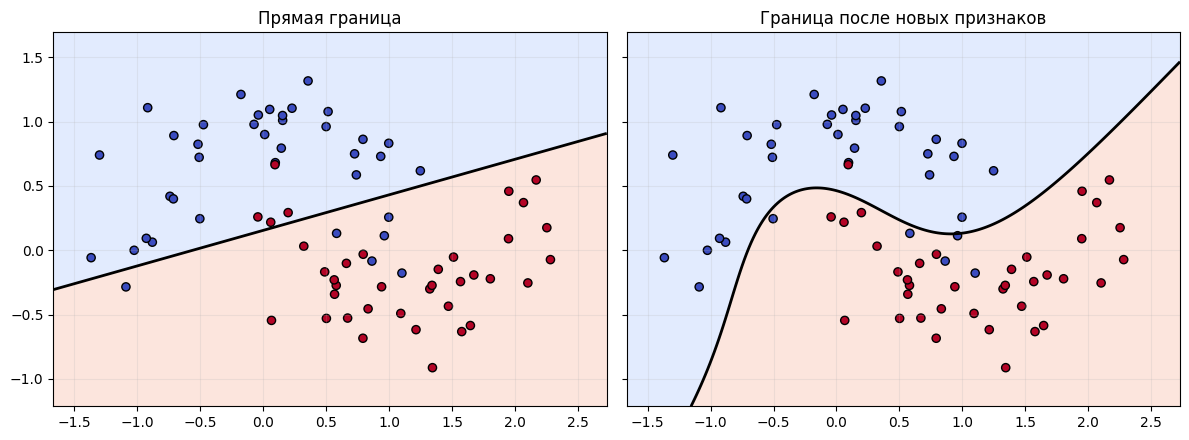

In [87]:
from sklearn.datasets import make_moons
from sklearn.preprocessing import PolynomialFeatures

X_moons, y_moons = make_moons(n_samples=250, noise=0.22, random_state=42)
moon_train, moon_test, ym_train, ym_test = train_test_split(
    X_moons, y_moons, test_size=0.3, random_state=42, stratify=y_moons
)

plain_moon = LogisticRegression().fit(moon_train, ym_train)
poly = PolynomialFeatures(degree=3, include_bias=False)
moon_train_poly = poly.fit_transform(moon_train)
moon_test_poly = poly.transform(moon_test)
curved_moon = LogisticRegression(max_iter=2000).fit(moon_train_poly, ym_train)

print(f'Accuracy с прямой границей: {accuracy_score(ym_test, plain_moon.predict(moon_test)):.3f}')
print(f'Accuracy с новыми признаками: {accuracy_score(ym_test, curved_moon.predict(moon_test_poly)):.3f}')

# Нарисуем обе границы на одной и той же сетке.
mx1 = np.linspace(X_moons[:, 0].min() - 0.3, X_moons[:, 0].max() + 0.3, 250)
mx2 = np.linspace(X_moons[:, 1].min() - 0.3, X_moons[:, 1].max() + 0.3, 250)
mxx1, mxx2 = np.meshgrid(mx1, mx2)
moon_grid = np.column_stack([mxx1.ravel(), mxx2.ravel()])
plain_surface = plain_moon.predict_proba(moon_grid)[:, 1].reshape(mxx1.shape)
curved_surface = curved_moon.predict_proba(poly.transform(moon_grid))[:, 1].reshape(mxx1.shape)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharex=True, sharey=True)
for ax, surface, title in [
    (axes[0], plain_surface, 'Прямая граница'),
    (axes[1], curved_surface, 'Граница после новых признаков'),
]:
    ax.contourf(mxx1, mxx2, surface, levels=[0, 0.5, 1], cmap='coolwarm', alpha=0.25)
    ax.contour(mxx1, mxx2, surface, levels=[0.5], colors='black', linewidths=2)
    ax.scatter(moon_test[:, 0], moon_test[:, 1], c=ym_test, cmap='coolwarm', edgecolor='black', s=35)
    ax.set_title(title); ax.grid(alpha=0.2)
plt.tight_layout(); plt.show()


## 23. Ограничения интерпретации и экстраполяции

Коэффициенты и вероятности логрег описывают связь **внутри диапазона обучающих данных**. Далеко за пределами train прогнозы могут быть ненадёжными.


## 24. Калибровка вероятностей *

Предсказанные вероятности не гарантированно совпадают с частотами событий на новых данных. **Калибровка** (например, isotonic или Platt) выравнивает вероятности по validation. После внедрения качество и калибровку мониторят на свежих данных.


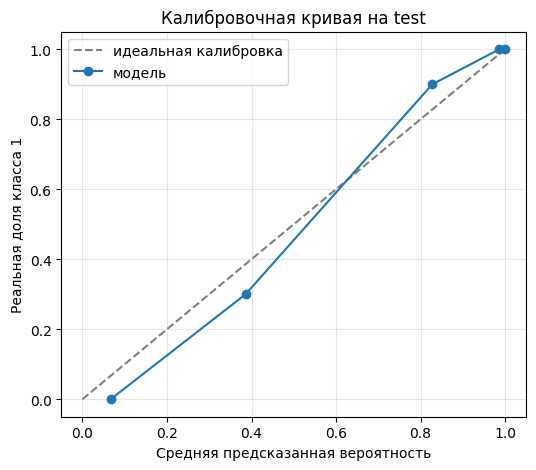

Brier score: 0.041 (меньше — лучше)
Brier score константы: 0.230


In [88]:
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

observed, predicted = calibration_curve(y_test, p_test, n_bins=5, strategy='quantile')
plt.figure(figsize=(6, 5))
plt.plot([0, 1], [0, 1], '--', color='gray', label='идеальная калибровка')
plt.plot(predicted, observed, marker='o', label='модель')
plt.xlabel('Средняя предсказанная вероятность')
plt.ylabel('Реальная доля класса 1')
plt.title('Калибровочная кривая на test')
plt.grid(alpha=0.3); plt.legend(); plt.show()
print(f'Brier score: {brier_score_loss(y_test, p_test):.3f} (меньше — лучше)')
baseline_probability = np.full_like(p_test, y_train.mean())
print(f'Brier score константы: {brier_score_loss(y_test, baseline_probability):.3f}')


## 25. Порядок работы с задачей классификации

Краткий чек-лист, который мы прошли в этом блокноте:

1. Определить объект, признаки и положительный класс.
2. Подготовить данные и **сразу разделить** их на train, validation и test.
3. Изучить доли классов и построить простой baseline.
4. Обучить логистическую регрессию только на train.
5. Получить вероятности и матрицу ошибок на validation.
6. Выбрать метрики по цене FP и FN.
7. Настроить порог на validation.
8. При необходимости применить масштабирование, регуляризацию или веса классов — снова обучая преобразования только на train.
9. **Один раз** оценить финальный вариант на test.
10. Зафиксировать ограничения и следить за качеством после внедрения.

> **Главная мысль.** Логистическая регрессия сначала вычисляет линейную комбинацию признаков, затем превращает её в оценку вероятности с помощью сигмоиды. Класс появляется только после выбора порога, а качество нельзя описать одной универсальной метрикой.
